In [79]:
import numpy as np 
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

In [80]:
import os
import pathlib

**EXTRACTION**

In [81]:
def list_files(path, dict_images=None):
    if dict_images is None:
        dict_images = {
            "file_path": [],
            "dir_name": [], 
            "file_name": [],
            "format": [],
            "resolution": [],
            "ratio": [],
            "mode": [],
            "file_size_mb": []
        }
    
    for entry in os.scandir(path): 
        if entry.is_file():

            if not entry.name.lower().endswith(('.png', '.jpg', '.jpeg')):
                continue
            
            actual_dir = pathlib.Path(entry.path).parent.name
            file_name = os.path.splitext(entry.name)[0]
            file_size = os.path.getsize(entry.path)

            try:
                with Image.open(entry.path) as img:
                    img_width, img_height = img.size
                    if img_height == 0:
                        continue

                    img_format, img_mode, img_resolution, img_ratio = img.format, img.mode, img_width*img_height, round(img_width/img_height, 2)

                    dict_images["file_path"].append(entry.path)
                    dict_images["dir_name"].append(actual_dir)
                    dict_images["file_name"].append(file_name)
                    dict_images["format"].append(img_format)
                    dict_images["resolution"].append(img_resolution)
                    dict_images["ratio"].append(img_ratio)
                    dict_images["mode"].append(img_mode)
                    dict_images["file_size_mb"].append(file_size / (1024**2))

            except Exception as e:
                continue

        elif entry.is_dir():
            dict_images =list_files(entry.path, dict_images)

    return dict_images

In [82]:
directory_reid_cat = 'C:\\Users\\castr\\OneDrive\\Desktop\\proyecto_ia\\proyecto\\data\\reid_cat'
dict_images_reid_cat = list_files(directory_reid_cat)
df_images_reid_cat = pd.DataFrame(dict_images_reid_cat)

**EDA REID CATS**

In [83]:
df_images_reid_cat.head()

,file_path,dir_name,file_name,format,resolution,ratio,mode,file_size_mb
0,C:\Users\castr\OneDrive\Desktop\proyecto_ia\pr...,0001,0001_000,JPEG,7990272,1.33,RGB,0.795949
1,C:\Users\castr\OneDrive\Desktop\proyecto_ia\pr...,0001,0001_001,JPEG,7990272,1.33,RGB,0.730849
2,C:\Users\castr\OneDrive\Desktop\proyecto_ia\pr...,0001,0001_002,JPEG,7990272,1.33,RGB,0.748957
3,C:\Users\castr\OneDrive\Desktop\proyecto_ia\pr...,0001,0001_003,JPEG,7990272,1.33,RGB,0.795803
4,C:\Users\castr\OneDrive\Desktop\proyecto_ia\pr...,0001,0001_004,JPEG,7990272,1.33,RGB,0.753259


In [84]:
df_images_reid_cat_modified = df_images_reid_cat.copy()

In [85]:
df_images_reid_cat_modified['format'].value_counts()

format
JPEG    13106
Name: count, dtype: int64

In [86]:
df_images_reid_cat_modified['mode'].value_counts()

mode
RGB    13106
Name: count, dtype: int64

**manejo de archivos anidados**

In [87]:
df_images_reid_cat_modified['dir_name'] = df_images_reid_cat_modified['dir_name'].apply(lambda x: x.split('_')[0] if '_' in x else x)
df_images_reid_cat_modified['dir_name'] = df_images_reid_cat_modified['dir_name'].apply(lambda x: int(x))

In [88]:
df_images_reid_cat_modified.head()

,file_path,dir_name,file_name,format,resolution,ratio,mode,file_size_mb
0,C:\Users\castr\OneDrive\Desktop\proyecto_ia\pr...,1,0001_000,JPEG,7990272,1.33,RGB,0.795949
1,C:\Users\castr\OneDrive\Desktop\proyecto_ia\pr...,1,0001_001,JPEG,7990272,1.33,RGB,0.730849
2,C:\Users\castr\OneDrive\Desktop\proyecto_ia\pr...,1,0001_002,JPEG,7990272,1.33,RGB,0.748957
3,C:\Users\castr\OneDrive\Desktop\proyecto_ia\pr...,1,0001_003,JPEG,7990272,1.33,RGB,0.795803
4,C:\Users\castr\OneDrive\Desktop\proyecto_ia\pr...,1,0001_004,JPEG,7990272,1.33,RGB,0.753259


In [89]:
print(f"El promedio de fotos por individuo es de: {df_images_reid_cat_modified['dir_name'].value_counts().mean():.0f}")

El promedio de fotos por individuo es de: 26


In [90]:
print(f"La cantidad de individuos presentes es de: {df_images_reid_cat_modified['dir_name'].value_counts().count()}")

La cantidad de individuos presentes es de: 509


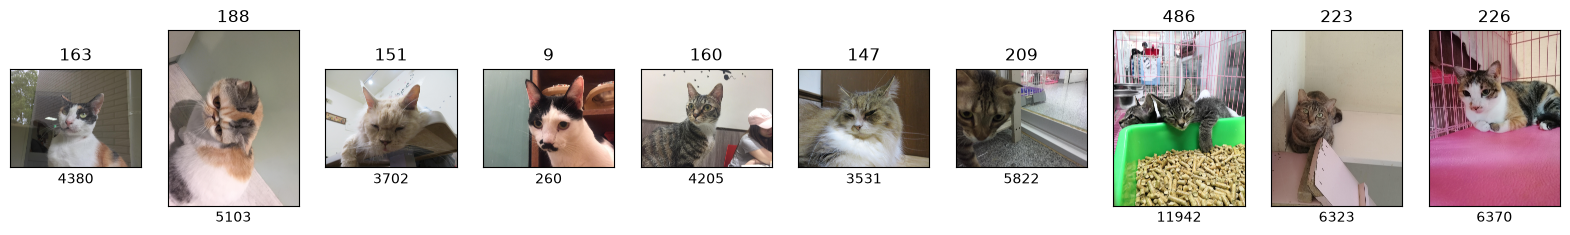

In [91]:
def plot_images(df, n=5, seed=None):
    df_sampled = df.sample(n=n, random_state=seed)
    plt.figure(figsize=(20, 4))
    for i, (_, row) in zip(range(n), df_sampled.iterrows()):
        title = df_sampled['dir_name'].iloc[i]
        with Image.open(row['file_path']) as img:
            plt.subplot(1, n, i+1)
            plt.imshow(img)
            plt.title(title)
            plt.xlabel(_)
            plt.xticks([])
            plt.yticks([])
    
plot_images(df_images_reid_cat_modified, n=10)

In [92]:
conteo_reid_cat = df_images_reid_cat_modified['dir_name'].value_counts()

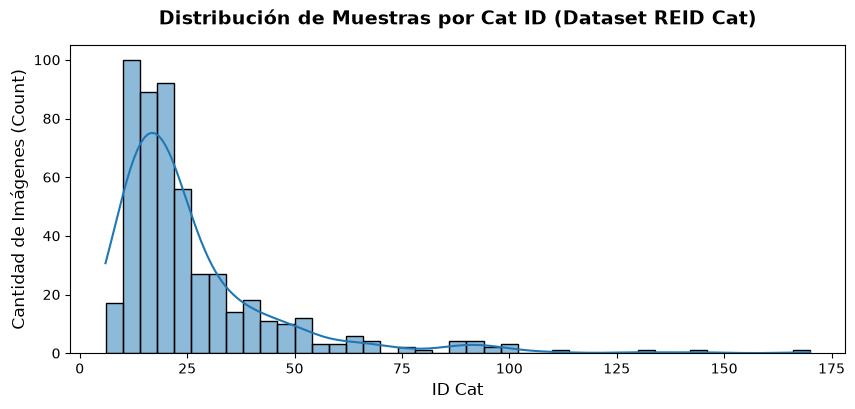

In [93]:
plt.figure(figsize=(10, 4))
plt.title('Distribución de Muestras por Cat ID (Dataset REID Cat)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('ID Cat', fontsize=12)
plt.ylabel('Cantidad de Imágenes (Count)', fontsize=12)
sns.histplot(conteo_reid_cat.values,  kde=True)
plt.show()

In [94]:
def plot_resolution_vs_file_size(df, class_df=None):
    plt.figure(figsize=(10, 4))
    if class_df == None:
        plt.title(f"Resolution vs File Size (MB)", fontsize=10, color='black')
    else: 
        plt.title(f"{class_df} - Resolution vs File Size (MB)", fontsize=10, color='black')
    sns.scatterplot(
        data=df,
        x='resolution', 
        y='file_size_mb',
        hue='format', 
        style='format',
        alpha=0.5
    )
    plt.grid()
    plt.show()

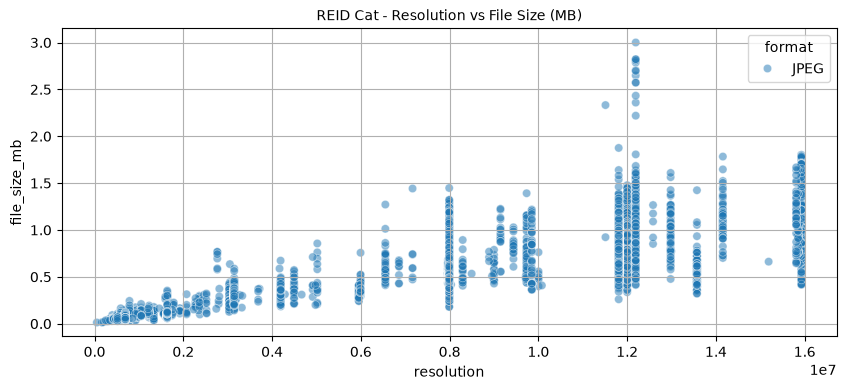

In [95]:
plot_resolution_vs_file_size(df_images_reid_cat_modified, class_df='REID Cat')

In [96]:
def file_size_vs_format(df, class_df=None):
    plt.figure(figsize=(15, 4))
    plt.subplot(1, 2, 1)
    prefix = f"{class_df} - " if class_df is not None else ""

    sns.boxplot(
        data=df,
        y='file_size_mb',
        x='format',
        hue='format'
    )
    plt.title(f"{prefix}File Size (MB) vs Format")
    plt.grid()

    plt.subplot(1, 2, 2)
    sns.boxplot(
        data=df,
        y='resolution',
        x='format',
        hue='format'
    )
    plt.title(f"{prefix}Resolition vs Format")
    plt.grid()

    plt.show()

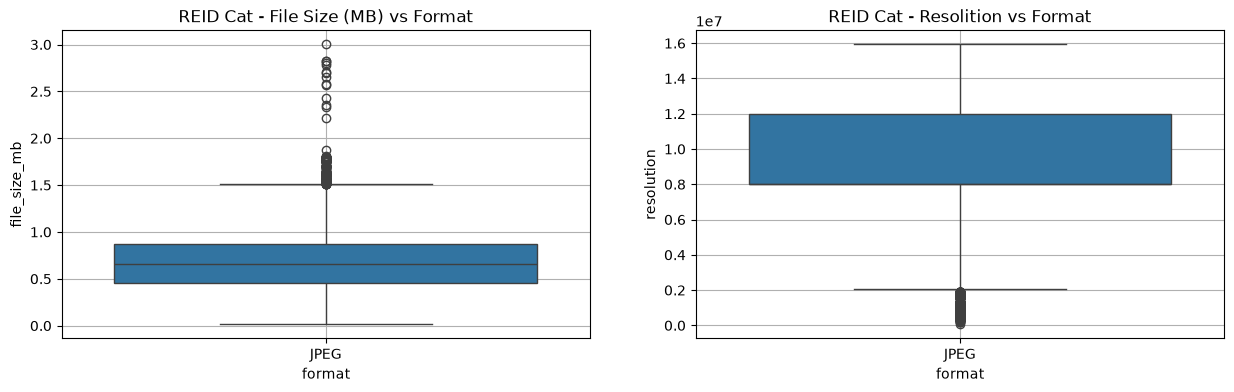

In [97]:
file_size_vs_format(df_images_reid_cat_modified, 'REID Cat')

In [98]:
df_images_reid_cat_modified['orientation'] = df_images_reid_cat_modified['ratio'].apply(
    lambda x: 'square' if 0.97 <= x <= 1.03 else 'vertical' if x < 1 else 'horizontal'
)

In [99]:
conteo_groupby_reid_cat = df_images_reid_cat_modified.groupby(['dir_name', 'orientation'], group_keys=False).size()
conteo_reid_cat_orientation = pd.DataFrame(conteo_groupby_reid_cat)
conteo_reid_cat_orientation = conteo_reid_cat_orientation.reset_index().rename(columns={0: 'conteo'})

In [100]:
conteo_reid_cat_orientation

,dir_name,orientation,conteo
0,1,horizontal,17
1,2,horizontal,20
2,3,horizontal,15
3,4,horizontal,56
4,5,horizontal,41
...,...,...,...
775,512,vertical,15
776,513,vertical,45
777,514,vertical,32
778,515,vertical,50


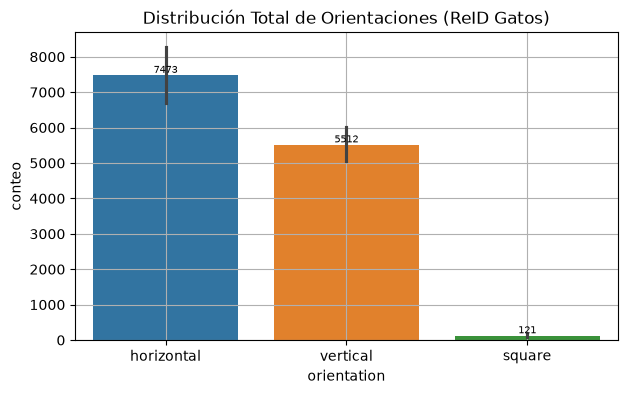

In [101]:
plt.figure(figsize=(7, 4))
ax = sns.barplot(
    data=conteo_reid_cat_orientation, 
    y='conteo', 
    x='orientation', 
    estimator='sum', 
    hue='orientation'
)
for container in ax.containers:
    ax.bar_label(container, fontsize=7.5)
    
plt.title('Distribución Total de Orientaciones (ReID Gatos)')
plt.grid()
plt.show()

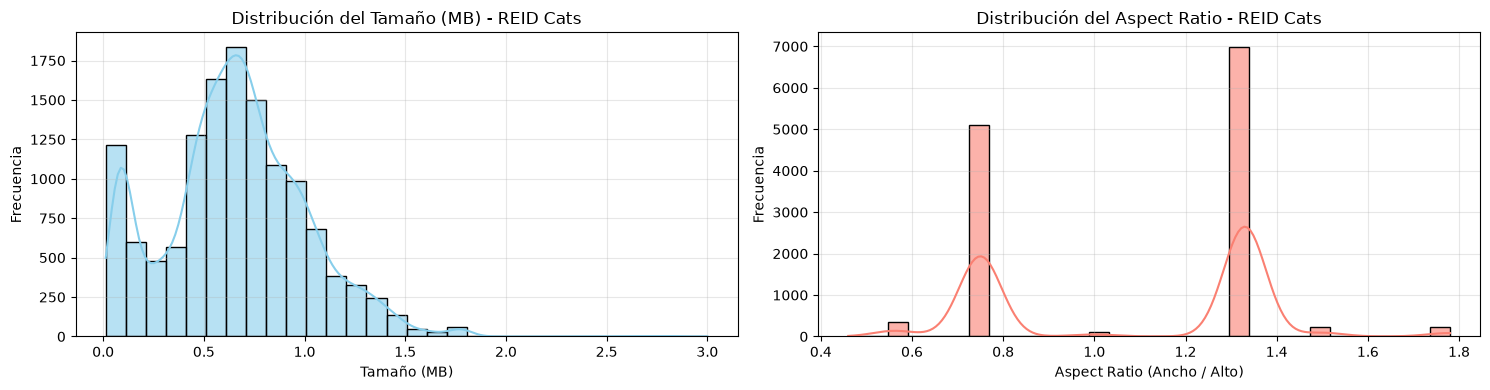

In [102]:
def plot_reid_distributions(df, title_prefix="REID Gatos"):
    plt.figure(figsize=(15, 4))

    plt.subplot(1, 2, 1)
    sns.histplot(
        data=df,
        x='file_size_mb',
        bins=30,
        kde=True,
        color='skyblue',
        alpha=0.6
    )
    plt.title(f'Distribución del Tamaño (MB) - {title_prefix}')
    plt.xlabel('Tamaño (MB)')
    plt.ylabel('Frecuencia')
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    sns.histplot(
        data=df,
        x='ratio',
        bins=30,
        kde=True,
        color='salmon',
        alpha=0.6
    )
    plt.title(f'Distribución del Aspect Ratio - {title_prefix}')
    plt.xlabel('Aspect Ratio (Ancho / Alto)')
    plt.ylabel('Frecuencia')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
plot_reid_distributions(df_images_reid_cat_modified, title_prefix="REID Cats")

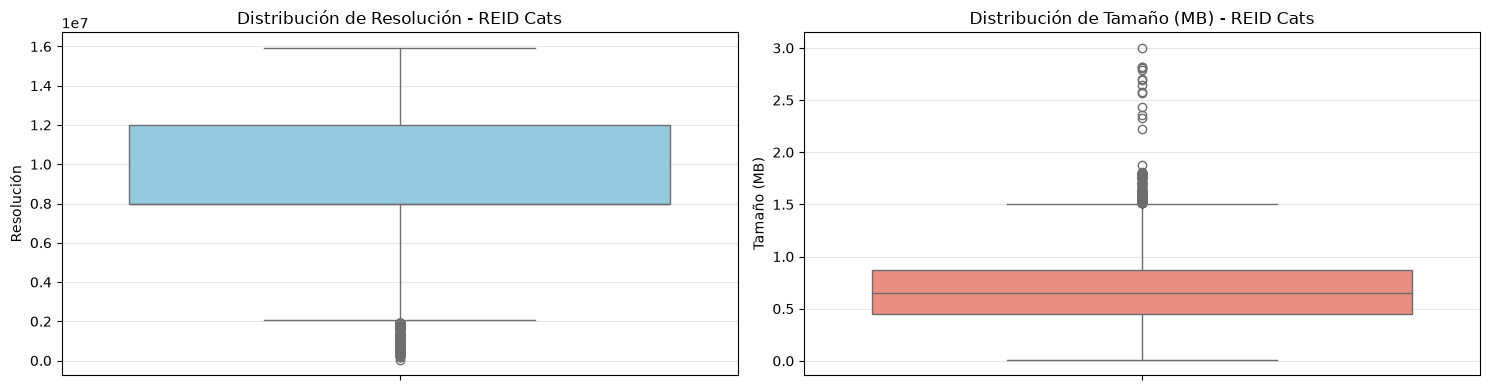

In [103]:
def plot_reid_boxplots(df, title_prefix="REID Gatos"):
    plt.figure(figsize=(15, 4))

    plt.subplot(1, 2, 1)
    sns.boxplot(
        data=df,
        y='resolution',
        color='skyblue'
    )
    plt.title(f'Distribución de Resolución - {title_prefix}')
    plt.ylabel('Resolución')
    plt.grid(True, axis='y', alpha=0.3)

    plt.subplot(1, 2, 2)
    sns.boxplot(
        data=df,
        y='file_size_mb',
        color='salmon'
    )
    plt.title(f'Distribución de Tamaño (MB) - {title_prefix}')
    plt.ylabel('Tamaño (MB)')
    plt.grid(True, axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

# Para llamarla:
plot_reid_boxplots(df_images_reid_cat_modified, title_prefix="REID Cats")